# Connect 4 Transformer
## Training Notebook (ViT-Style Architecture)

This notebook implements a Vision Transformer (ViT) architecture adapted for Connect 4, based on a ViT template introduced in coursework (`topic1-transformers.ipynb`) and extended here for this project's dataset and task.

**Key details:**
- ViT-style structure with a learnable class token
- Pre-normalization transformer blocks
- Trained on the team's self-play dataset: (6, 7) format with +1/-1/0 values


---
## Step 1: Setup and Imports

In [ ]:
# Core libraries
import numpy as np
import tensorflow as tf
from tensorflow import keras
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import time

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {len(tf.config.list_physical_devices('GPU')) > 0}")

# Set seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

TensorFlow version: 2.19.0
GPU available: False


---
## Step 2: Upload Franco's Dataset

Upload the `.npz` file Franco sent you

In [ ]:
# Upload files
from google.colab import files

print("Upload Franco's dataset file: connect4_mcts_dataset.npz")
uploaded = files.upload()
print("\n✅ Upload complete!")

Upload Franco's dataset file: connect4_mcts_dataset.npz


Saving connect4_mcts_dataset.npz to connect4_mcts_dataset.npz

✅ Upload complete!


---
## Step 3: Load and Preprocess Data

Franco's data is in (6, 7) format. We need to convert it to patches for the transformer.

In [ ]:
# Load dataset
data = np.load('connect4_mcts_dataset.npz')
X_raw = data['X']  # Shape: (N, 6, 7) with values +1, -1, 0
y = data['y']      # Shape: (N,) with values 0-6 (column indices)

print("=== DATASET INFO ===")
print(f"Boards shape: {X_raw.shape}")
print(f"Moves shape: {y.shape}")
print(f"Total examples: {len(X_raw):,}")
print(f"Board values: {np.unique(X_raw)}")
print(f"Move range: {y.min()} to {y.max()}")

=== DATASET INFO ===
Boards shape: (123476, 6, 7)
Moves shape: (123476,)
Total examples: 123,476
Board values: [-1  0  1]
Move range: 0 to 6


In [ ]:
# Convert boards to patch format for transformer
# ViT approach: treat each cell as a "patch" (like a pixel in an image)
# We'll flatten the 6×7 board into 42 patches (one per cell)

def board_to_patches(boards):
    """
    Convert (N, 6, 7) boards to (N, 42, 1) patches.
    Each cell becomes one patch.

    Why 42? 6 rows × 7 columns = 42 cells
    Why 1? Each cell has one value (+1, -1, or 0)
    """
    N = boards.shape[0]
    # Reshape: (N, 6, 7) → (N, 42, 1)
    patches = boards.reshape(N, 42, 1)
    return patches.astype(np.float32)

# Convert to patches
X = board_to_patches(X_raw)

print("\n=== AFTER CONVERSION ===")
print(f"Patches shape: {X.shape}")
print(f"Each board: 42 patches, 1 value per patch")
print(f"Memory: {X.nbytes / 1024 / 1024:.2f} MB")


=== AFTER CONVERSION ===
Patches shape: (123476, 42, 1)
Each board: 42 patches, 1 value per patch
Memory: 19.78 MB


In [ ]:
# Split into train and validation
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("=== DATA SPLIT ===")
print(f"Training: {len(X_train):,} examples")
print(f"Validation: {len(X_val):,} examples")
print(f"Split: {len(X_train)/len(X)*100:.1f}% train, {len(X_val)/len(X)*100:.1f}% val")

=== DATA SPLIT ===
Training: 98,780 examples
Validation: 24,696 examples
Split: 80.0% train, 20.0% val


---
## Step 4: Build the Transformer Architecture

Adapted from a ViT approach introduced in coursework (`topic1-transformers.ipynb`)

In [ ]:
# Custom layers (adapted from ViT course template)

class PositionalIndex(tf.keras.layers.Layer):
    """Generate positional indices for embeddings"""
    def call(self, x):
        bs = tf.shape(x)[0]  # batch size
        number_of_vectors = tf.shape(x)[1]  # number of patches (42 for Connect 4)
        indices = tf.range(number_of_vectors)  # 0, 1, 2, ..., 41
        indices = tf.expand_dims(indices, 0)  # shape: (1, 42)
        return tf.tile(indices, [bs, 1])  # repeat for each batch: (batch, 42)


class ClassTokenIndex(tf.keras.layers.Layer):
    """Generate index for class token"""
    def call(self, x):
        bs = tf.shape(x)[0]  # batch size
        number_of_vectors = 1  # we only want 1 class token
        indices = tf.range(number_of_vectors)  # just [0]
        indices = tf.expand_dims(indices, 0)
        return tf.tile(indices, [bs, 1])  # (batch, 1)

print("✅ Custom layers defined")

✅ Custom layers defined


In [ ]:
def build_connect4_vit(
    n=6,              # rows
    m=7,              # columns
    patch_size=1,     # each cell is one value
    hidden_dim=64,    # embedding dimension
    num_layers=4,     # number of transformer blocks
    num_heads=4,      # attention heads
    key_dim=16,       # key dimension for attention
    value_dim=32,     # value dimension
    mlp_dim=64,       # MLP hidden dimension
    dropout_rate=0.1, # dropout
    num_classes=7     # output: 7 columns
):
    """
    Build Vision Transformer for Connect 4, adapted from a ViT course template.

    Key features:
    - Class token (like ViT paper)
    - Pre-normalization (normalize before attention)
    - Positional embeddings
    """

    # Input: (batch, 42, 1) - 42 patches with 1 value each
    inp = tf.keras.layers.Input(shape=(n*m, patch_size))

    # Project patches to hidden dimension
    # (batch, 42, 1) → (batch, 42, hidden_dim)
    mid = tf.keras.layers.Dense(hidden_dim, use_bias=False)(inp)

    # Add positional embeddings
    # This tells the model WHERE each patch is on the board
    inp2 = PositionalIndex()(inp)
    emb = tf.keras.layers.Embedding(
        input_dim=n*m,  # 42 positions
        output_dim=hidden_dim
    )(inp2)
    mid = tf.keras.layers.Add()([mid, emb])

    # Create and prepend class token
    # The class token will "summarize" the entire board
    tokenInd = ClassTokenIndex()(mid)
    token = tf.keras.layers.Embedding(
        input_dim=1,
        output_dim=hidden_dim
    )(tokenInd)
    # Concatenate: [class_token, patch_1, patch_2, ..., patch_42]
    # Now we have 43 tokens total (1 class + 42 patches)
    mid = tf.keras.layers.Concatenate(axis=1)([token, mid])

    # Transformer blocks (pre-normalization, per ViT course template)
    for l in range(num_layers):
        # Pre-normalization
        ln = tf.keras.layers.LayerNormalization()(mid)

        # Multi-Head Self-Attention
        mha = tf.keras.layers.MultiHeadAttention(
            num_heads=num_heads,
            key_dim=key_dim,
            value_dim=value_dim
        )(ln, ln, ln)  # self-attention: query=key=value

        # Add residual connection
        add = tf.keras.layers.Add()([mid, mha])

        # Pre-normalization for MLP
        ln = tf.keras.layers.LayerNormalization()(add)

        # Feed-Forward Network (MLP)
        den = tf.keras.layers.Dense(mlp_dim, activation='gelu')(ln)
        den = tf.keras.layers.Dropout(dropout_rate)(den)
        den = tf.keras.layers.Dense(hidden_dim)(den)
        den = tf.keras.layers.Dropout(dropout_rate)(den)

        # Add residual connection
        mid = tf.keras.layers.Add()([den, add])

    # Extract class token (first token)
    # mid shape: (batch, 43, hidden_dim)
    # We only take the first token (index 0)
    fl = mid[:, 0, :]  # (batch, hidden_dim)

    # Final normalization and classification
    ln = tf.keras.layers.LayerNormalization()(fl)
    clas = tf.keras.layers.Dense(num_classes, activation='softmax')(ln)

    # Create model
    mod = tf.keras.models.Model(inp, clas, name='Connect4_ViT')

    return mod

print("✅ Transformer builder function defined")

✅ Transformer builder function defined


In [ ]:
# Build the model with chosen hyperparameters
print("=== BUILDING TRANSFORMER ===")

model = build_connect4_vit(
    n=6,
    m=7,
    patch_size=1,
    hidden_dim=64,      # Try: 32, 64, 128
    num_layers=4,       # Try: 2, 4, 6
    num_heads=4,        # Try: 2, 4, 8
    key_dim=16,         # Usually hidden_dim // num_heads
    value_dim=32,       # Usually key_dim * 2
    mlp_dim=64,         # Usually same as hidden_dim
    dropout_rate=0.1,
    num_classes=7
)

# Display architecture
model.summary()

print(f"\n✅ Model built with {model.count_params():,} parameters")

=== BUILDING TRANSFORMER ===


Model: "Connect4_ViT"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 42, 1)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ positional_index    │ (None, 42)        │          0 │ input_layer[0][0] │
│ (PositionalIndex)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 42, 64)    │         64 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 42, 64)    │      2,688 │ positional_index… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 42, 64)    │          0 │ dense[0][0],      │
│                     │                   │            │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ class_token_index   │ (None, 1)         │          0 │ add[0][0]         │
│ (ClassTokenIndex)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 1, 64)     │         64 │ class_token_inde… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 43, 64)    │          0 │ embedding_1[0][0… │
│ (Concatenate)       │                   │            │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 43, 64)    │        128 │ concatenate[0][0] │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 43, 64)    │     24,896 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
│                     │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 43, 64)    │          0 │ concatenate[0][0… │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 43, 64)    │        128 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 43, 64)    │      4,160 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 43, 64)    │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 43, 64)    │      4,160 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 43, 64)    │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 43, 64)    │          0 │ dropout_2[0][0],  │
│                     │                   │            │ add_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 43, 64)    │        128 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                 

 Total params: 137,287 (536.28 KB)

 Trainable params: 137,287 (536.28 KB)

 Non-trainable params: 0 (0.00 B)


✅ Model built with 137,287 parameters


---
## Step 5: Compile and Train

In [ ]:
# Compile model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Callbacks
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_accuracy',
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1
    )
]

print("✅ Model compiled")

✅ Model compiled


In [ ]:
# Train the model
print("=== STARTING TRAINING ===")
print("This will take 30-60 minutes...\n")

start_time = time.time()

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    batch_size=128,
    epochs=50,
    callbacks=callbacks,
    verbose=1
)

training_time = time.time() - start_time
print(f"\n✅ Training completed in {training_time/60:.1f} minutes!")

=== STARTING TRAINING ===
This will take 30-60 minutes...

Epoch 1/50
772/772 ━━━━━━━━━━━━━━━━━━━━ 395s 492ms/step - accuracy: 0.2369 - loss: 1.8501 - val_accuracy: 0.3438 - val_loss: 1.5471 - learning_rate: 0.0010
Epoch 2/50
772/772 ━━━━━━━━━━━━━━━━━━━━ 379s 489ms/step - accuracy: 0.3462 - loss: 1.5489 - val_accuracy: 0.3608 - val_loss: 1.5259 - learning_rate: 0.0010
Epoch 3/50
772/772 ━━━━━━━━━━━━━━━━━━━━ 378s 489ms/step - accuracy: 0.3641 - loss: 1.5187 - val_accuracy: 0.3679 - val_loss: 1.5181 - learning_rate: 0.0010
Epoch 4/50
772/772 ━━━━━━━━━━━━━━━━━━━━ 378s 489ms/step - accuracy: 0.3702 - loss: 1.5042 - val_accuracy: 0.3759 - val_loss: 1.5068 - learning_rate: 0.0010
Epoch 5/50
772/772 ━━━━━━━━━━━━━━━━━━━━ 380s 487ms/step - accuracy: 0.3776 - loss: 1.4955 - val_accuracy: 0.3814 - val_loss: 1.4960 - learning_rate: 0.0010
Epoch 6/50
772/772 ━━━━━━━━━━━━━━━━━━━━ 394s 502ms/step - accuracy: 0.3809 - loss: 1.4881 - val_accuracy: 0.3812 - val_loss: 1.4915 - learning_rate: 0.0010
Epoch

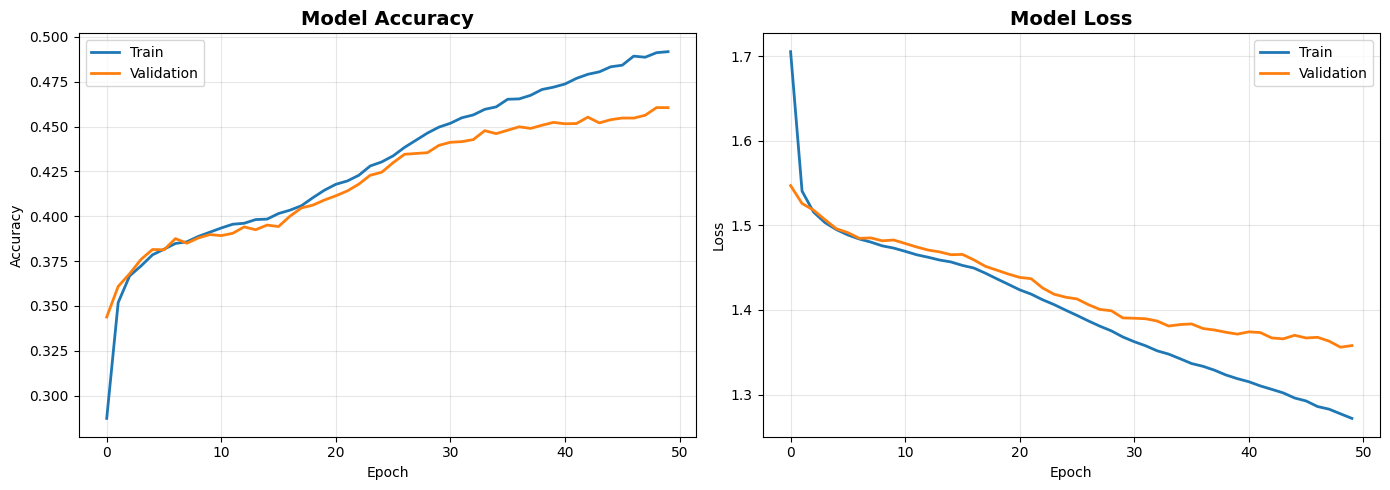


=== TRAINING SUMMARY ===
Final train accuracy: 0.4917
Final val accuracy: 0.4605
Best val accuracy: 0.4606


In [ ]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(history.history['accuracy'], label='Train', linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Validation', linewidth=2)
axes[0].set_title('Model Accuracy', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Loss
axes[1].plot(history.history['loss'], label='Train', linewidth=2)
axes[1].plot(history.history['val_loss'], label='Validation', linewidth=2)
axes[1].set_title('Model Loss', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('transformer_training.png', dpi=150)
plt.show()

print("\n=== TRAINING SUMMARY ===")
print(f"Final train accuracy: {history.history['accuracy'][-1]:.4f}")
print(f"Final val accuracy: {history.history['val_accuracy'][-1]:.4f}")
print(f"Best val accuracy: {max(history.history['val_accuracy']):.4f}")

---
## Step 6: Save Model

In [ ]:
# Save in .h5 format for Muzaffar
#model.save('connect4_transformer.h5')
model.save('connect4_transformer.keras')
print("✅ Model saved as connect4_transformer.h5")

# Download
#files.download('connect4_transformer.h5')
#files.download('transformer_training.png')
files.download('connect4_transformer.keras')

print("\n✅ Files downloaded!")

✅ Model saved as transformer_professor_style.h5


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ Files downloaded!


---
## Step 7: Evaluate and Save Results

In [ ]:
# Final evaluation
val_loss, val_acc = model.evaluate(X_val, y_val, verbose=0)

results = {
    'Model': 'Transformer (ViT)',
    'Validation Accuracy': f"{val_acc*100:.2f}%",
    'Parameters': f"{model.count_params():,}",
    'Training Time (min)': f"{training_time/60:.1f}",
    'Architecture': 'ViT with Class Token',
    'Hidden Dim': 64,
    'Num Layers': 4,
    'Num Heads': 4
}

results_df = pd.DataFrame([results])
print(results_df.T)

# Save results
results_df.to_csv('transformer_results.csv', index=False)
files.download('transformer_results.csv')

print(f"\n\n🎉 FINAL ACCURACY: {val_acc*100:.2f}%")

                                                 0
Model                Transformer (Professor Style)
Validation Accuracy                         46.06%
Parameters                                 137,287
Training Time (min)                          330.7
Architecture                  ViT with Class Token
Hidden Dim                                      64
Num Layers                                       4
Num Heads                                        4


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>



🎉 FINAL ACCURACY: 46.06%


---
## Summary

You've trained a transformer using a ViT architecture adapted from a course template!

**Files to download:**
1. `connect4_transformer.h5` - Give to Muzaffar
2. `transformer_training.png` - For the write-up
3. `transformer_results.csv` - For comparison

**Next step:** Compare this with Franco's CNN!
